<a href="https://colab.research.google.com/github/Destructor169/ES670MM/blob/main/labs/ES670_Assignment_3_The_Signal_Reconstruction_Protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Project AETHER: Assignment 3 — *“The Signal Reconstruction Protocol”*

**Course:** Matrix Methods for Signal Processing, ML, and Data Science  
**Name:**  Aditya Kumar\
**Roll Number:**  22110015\
**Role:** Data Forensics Officer (Class IV)  
**Mission Status:** RECONSTRUCTION PHASE  
**Date:** March 23, 2140  

---

##  Mission Briefing

Officer,

Following successful reconstruction of the Artifact’s surface, we now shift to **data-driven signal reconstruction and prediction**.

Recovered logs from the AETHER station reveal incomplete behavioral data of system agents. These logs are sparse, noisy, and partially corrupted. Your task is to:

1. Recover missing interactions using **matrix factorization**
2. Build a predictive model using **Singular Value Decomposition (SVD)**
3. Analyze interpolation using **Lagrange Polynomials**

This assignment tests your ability to reconstruct signals using **linear algebra from first principles**.

---

## Mission Constraints (IMPORTANT)

This assignment is designed to evaluate your understanding of **core matrix algorithms and their implementation from first principles**.

---

### NOT ALLOWED

You must **NOT use high-level matrix factorization or solver routines**, including:

- `numpy.linalg.svd`
- `numpy.linalg.solve`, `numpy.linalg.inv`, `numpy.linalg.lstsq`
- Any function from `scipy.linalg`
- Any external library that performs matrix decomposition automatically

---

### ALLOWED

You may use:

- Basic NumPy operations:
  - array creation and manipulation
  - indexing and slicing
  - `np.dot`, `@` (matrix multiplication)
- **Eigen decomposition**:
  - `numpy.linalg.eig` (allowed for building SVD from first principles)
- Python control structures:
  - loops, conditionals
- Visualization libraries:
  - `matplotlib`



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from google.colab import drive
drive.mount('/content/drive')
DATASET_PATH = "/content/drive/MyDrive/ES670MM/dataset/C/data.csv"

Mounted at /content/drive


In [2]:
def plot_heatmap(matrix, title="Heatmap"):
    """
    Plot heatmap of a matrix.

    Args:
        matrix (np.ndarray)
        title (str)
    """

    plt.figure(figsize=(8, 6))
    plt.imshow(matrix, aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Items")
    plt.ylabel("Users")
    plt.tight_layout()
    plt.show()

def split_dataset(df, test_ratio=0.2, seed=42):
    """
    Split dataset into train and test.

    Ensures each user has at least 1 rating in train.

    Returns:
        train_df, test_df
    """
    np.random.seed(seed)

    train_list = []
    test_list = []

    for user, group in df.groupby("user_id"):
        items = group.sample(frac=1, random_state=seed)  # shuffle

        test_size = max(1, int(len(items) * test_ratio))

        test = items.iloc[:test_size]
        train = items.iloc[test_size:]

        # Ensure at least 1 in train
        if len(train) == 0:

            train = test.iloc[:1]
            test = test.iloc[1:]

        train_list.append(train)
        test_list.append(test)

    train_df = pd.concat(train_list)
    test_df = pd.concat(test_list)

    return train_df, test_df


def load_dataset(file_path):
    """
    Load MovieLens dataset using pandas.

    Returns:
        df (DataFrame)
    """
    df = pd.read_csv(file_path)
    print(df.head())
    return df

#  Task 1 — Matrix Factorization for Recommendation Systems (7 marks)

---

##  Problem Overview

You are given a sparse **user-item interaction matrix**:

**$$
\mathbf{R} \in \mathbb{R}^{m \times n}
$$**

where:

- rows = users  
- columns = items  
- entries = ratings (0 indicates missing)

Your goal is to approximate:

**$$
\mathbf{R} \approx \mathbf{U} \mathbf{\Sigma} \mathbf{V}^\top
$$**

using **Singular Value Decomposition (SVD)**.

Go through this [blog](https://yeunun-choo.medium.com/singular-value-decomposition-in-a-movie-recommender-system-e3565ed42066) to understand the working of SVD in recomendation systems

---

##  Mathematical Formulation

SVD decomposes a matrix as:

**$$
\mathbf{R} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^\top
$$**

where:

- **$\mathbf{U}$** → left singular vectors (users)
- **$\mathbf{\Sigma}$** → singular values (importance)
- **$\mathbf{V}^\top$** → right singular vectors (items)

To reduce noise and dimensionality:

**$$
\mathbf{R}_k = \mathbf{U}_k \mathbf{\Sigma}_k \mathbf{V}_k^\top
$$**

---

##  Objectives

You must:

1. Construct the user-item matrix from raw data
2. Implement **SVD from scratch**
3. Reduce dimensionality using top-**k** components
4. Reconstruct missing ratings
5. Evaluate predictions using:
   - RMSE
   - Precision@K
6. Generate top-K recommendations

---

##  Required Implementations

Students must implement:

### 1. SVD from Scratch

You may use:

- Eigen decomposition of:

**$$
\mathbf{R}^\top \mathbf{R}
$$**

to compute singular vectors and values.

---

### 2. Low-Rank Approximation

Extract top-k components:

**$$
\mathbf{U}_k, \mathbf{\Sigma}_k, \mathbf{V}_k
$$**

---

### 3. Reconstruction

**$$
\hat{\mathbf{R}} = \mathbf{U}_k \mathbf{\Sigma}_k \mathbf{V}_k^\top
$$**

---

### 4. Evaluation

- RMSE on test entries
- Precision@K for recommendations

Please go through this [Link](https://medium.com/@m_n_malaeb/recall-and-precision-at-k-for-recommender-systems-618483226c54) for better understanding of precision@k calculation for recommender systems.

In [3]:
def create_user_item_matrix(df, all_user_ids, all_item_ids):
    """
    Create user-item matrix with consistent rows (users) and columns (items).
    Missing ratings are filled with 0.
    """

    user_index = {u:i for i,u in enumerate(all_user_ids)}
    item_index = {i:j for j,i in enumerate(all_item_ids)}

    R = np.zeros((len(all_user_ids), len(all_item_ids)))

    for _, row in df.iterrows():
        u = user_index[row["user_id"]]
        it = item_index[row["item_id"]]

        R[u, it] = row["rating"]

    return R

In [4]:
def compute_svd(R):
    """
    Compute SVD using eigen decomposition.

    R = U Σ V^T
    """

    RtR = np.dot(R.T, R)

    eigvals, V = np.linalg.eig(RtR)

    # sort descending
    idx = np.argsort(eigvals)[::-1]

    eigvals = eigvals[idx]
    V = V[:, idx]

    # remove tiny imaginary parts
    eigvals = np.real(eigvals)
    V = np.real(V)

    sigma = np.sqrt(np.maximum(eigvals, 0))

    U = np.zeros((R.shape[0], len(sigma)))

    for i in range(len(sigma)):

        if sigma[i] > 1e-10:

            U[:, i] = np.dot(R, V[:, i]) / sigma[i]

    U = np.real(U)

    Vt = V.T

    return U, sigma, Vt

def reduce_dimensions(U, sigma, Vt, k):
    """
    Keep top-k latent factors.
    """

    U_k = U[:, :k]

    sigma_k = np.zeros((k, k))
    for i in range(k):
        sigma_k[i,i] = sigma[i]

    Vt_k = Vt[:k, :]

    return U_k, sigma_k, Vt_k

In [5]:
def reconstruct_matrix(U_k, sigma_k, Vt_k):
    """
    Reconstruct predicted ratings.
    """

    return np.dot(np.dot(U_k, sigma_k), Vt_k)


def compute_rmse(R_test, R_pred):
    """
    Compute RMSE only on observed test entries.
    """

    mask = R_test > 0

    diff = R_test[mask] - R_pred[mask]

    mse = np.mean(diff**2)

    return np.sqrt(mse)

In [6]:

def precision_at_k(R_train, R_test, R_pred, k=5, threshold=3.5):
    """
    Precision@K using test ratings as ground truth.
    """

    precisions = []

    for user in range(R_train.shape[0]):

        # ignore items already seen in training
        unseen_mask = R_train[user] == 0

        scores = R_pred[user].copy()
        scores[~unseen_mask] = -np.inf

        top_k_items = np.argsort(scores)[::-1][:k]

        relevant = 0

        for item in top_k_items:
            if R_test[user, item] >= threshold:
                relevant += 1

        precisions.append(relevant / k)

    return np.mean(precisions)

In [7]:
def recommend_top_k(R_train, R_pred, k=5):
    """
    Recommend top-k unseen items per user.
    """

    recommendations = {}

    for user in range(R_train.shape[0]):

        unseen_mask = R_train[user] == 0

        scores = R_pred[user].copy()
        scores[~unseen_mask] = -np.inf

        top_items = np.argsort(scores)[::-1][:k]

        rec_list = []

        for item in top_items:

            rec_list.append({
                "item_id": int(item),
                "predicted_rating": float(round(scores[item],3))
            })

        recommendations[int(user)] = rec_list

    return recommendations

In [8]:
# Step 1: Load data
df = load_dataset(DATASET_PATH)

# Get all unique user IDs and item IDs from the full dataset for consistent matrix creation
all_user_ids = sorted(df['user_id'].unique())
all_item_ids = sorted(df['item_id'].unique())

# Step 2: Split dataset
train_df, test_df = split_dataset(df)

# Step 3: Create matrices with consistent user and item dimensions
R_train = create_user_item_matrix(train_df, all_user_ids, all_item_ids)
R_test = create_user_item_matrix(test_df, all_user_ids, all_item_ids)

print("Train matrix shape:", R_train.shape)
print("Test matrix shape:", R_test.shape)

# Step 4: Train model
U, sigma, Vt = compute_svd(R_train)

# Step 5: Reduce dimensions
k = 20
U_k, sigma_k, Vt_k = reduce_dimensions(U, sigma, Vt, k)

# Step 6: Reconstruct
R_pred = reconstruct_matrix(U_k, sigma_k, Vt_k)

# Step 7: Evaluate
rmse = compute_rmse(R_test, R_pred)
precision = precision_at_k(R_train, R_test, R_pred, k=5)

print("\nEvaluation Metrics:")
# print("RMSE:", round(rmse, 4))
print("Precision@5:", round(precision, 4))
print("RMSE:", round(float(rmse), 4))

# Step 8: Recommend
recommendations = recommend_top_k(R_train, R_pred, k=5)


rows = []

for user, recs in recommendations.items():
    row = {"user_id": user}

    for i, rec in enumerate(recs):
        item = rec["item_id"]
        score = rec["predicted_rating"]

        row[f"rank_{i+1}"] = f"{item} ({score:.2f})"

    rows.append(row)

df = pd.DataFrame(rows)

print("\nRecommendations Table:")
print(df.head())

   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596
Train matrix shape: (943, 1682)
Test matrix shape: (943, 1682)

Evaluation Metrics:
Precision@5: 0.3213
RMSE: 2.6191

Recommendations Table:
   user_id      rank_1      rank_2      rank_3      rank_4      rank_5
0        0  474 (4.08)  274 (3.02)  317 (2.99)  275 (2.95)  194 (2.92)
1        1  180 (2.35)  257 (2.29)   99 (2.13)  274 (1.99)  123 (1.83)
2        2  257 (2.06)  332 (1.71)  285 (1.46)  268 (1.34)  312 (1.32)
3        3  332 (1.52)  747 (1.44)  285 (1.37)  325 (1.27)  321 (1.23)
4        4  167 (3.29)    6 (2.94)  172 (2.79)  194 (2.71)  174 (2.53)


-1.0711989974829006


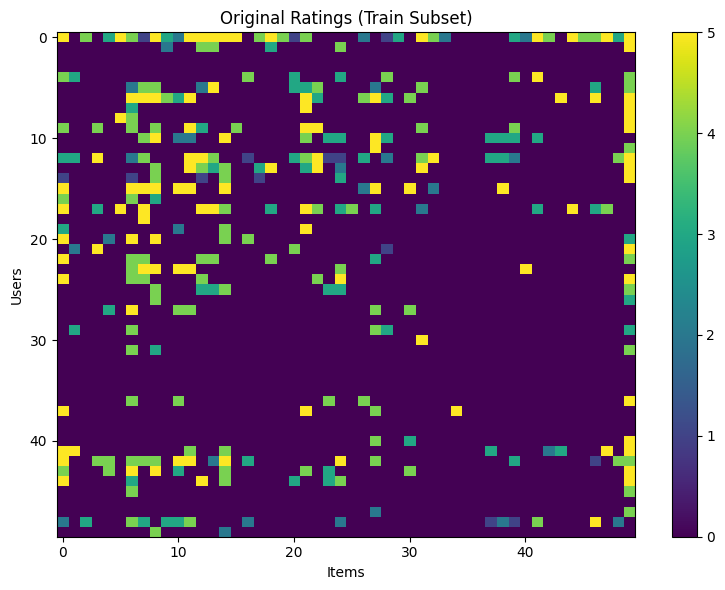

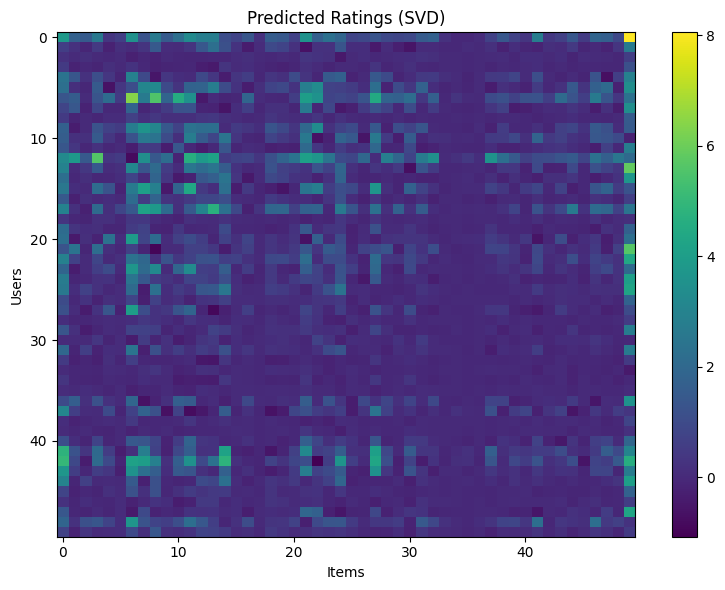

In [9]:
subset_users = 50
subset_items = 50

R_small = R_train[:subset_users, :subset_items]
R_pred_small = R_pred[:subset_users, :subset_items]
print(R_pred_small.min())

plot_heatmap(R_small, title="Original Ratings (Train Subset)")
plot_heatmap(R_pred_small, title="Predicted Ratings (SVD)")

Minimum predicted rating: -3.6740942627117956
Maximum predicted rating: 8.277782570315313
Values < 1: 1492913
Values > 5: 604


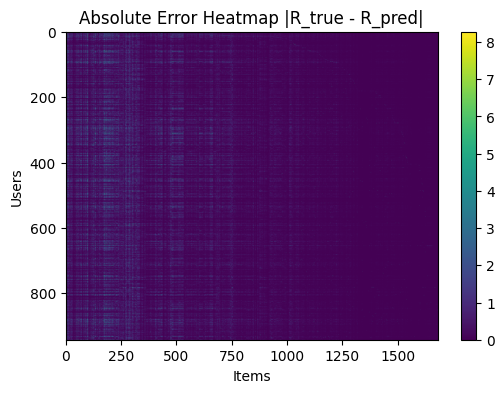

In [10]:
# Check prediction range
print("Minimum predicted rating:", np.min(R_pred))
print("Maximum predicted rating:", np.max(R_pred))

# Count invalid ratings
invalid_low = np.sum(R_pred < 1)
invalid_high = np.sum(R_pred > 5)

print("Values < 1:", invalid_low)
print("Values > 5:", invalid_high)

# Plot error heatmap (difference between true and predicted)
error_matrix = np.abs(R_test - R_pred)

plt.figure(figsize=(6,4))
plt.imshow(error_matrix, aspect='auto')
plt.title("Absolute Error Heatmap |R_true - R_pred|")
plt.xlabel("Items")
plt.ylabel("Users")
plt.colorbar()
plt.show()

In [11]:
# Clip ratings to valid range
R_pred_clipped = np.clip(R_pred, 1, 5)

# Compare RMSE before and after clipping
rmse_clipped = np.sqrt(np.mean((R_test[R_test > 0] - R_pred_clipped[R_test > 0])**2))

print("RMSE before clipping:", rmse)
print("RMSE after clipping:", rmse_clipped)

RMSE before clipping: 2.619058319278089
RMSE after clipping: 2.350340188999897


## Task 1 Critical Analysis
From the heat map provided, answer the following:

1. Do you observe any anomalies in the predicted matrix compared to the original? Check whether predicted ratings fall within the valid range (0, 5]. If not, explain why this happens.
2. Suggest improvements within the current setup (Do not use deep learning models).
3. Support your observations using code and visualizations (You can include your own visualization code).

# Task 1: Critical Analysis

---

## Heatmap Comparison

The heatmaps illustrate the discrepancy between the original sparse user–item rating matrix and the reconstructed matrix obtained via **Singular Value Decomposition (SVD)**.

The original rating matrix $R$ contains values in the valid range:
$$1 \le R_{ij} \le 5$$
where missing ratings are represented as zeros.

The reconstructed matrix is computed using truncated SVD:
$$R_k = U_k \Sigma_k V_k^T$$

**Where:**
* $U_k$: Latent user features.
* $\Sigma_k$: Diagonal matrix of singular values representing the importance of latent factors.
* $V_k^T$: Latent item features.
* $k$: The reduced dimension (rank).

---

## 1. Observed Anomalies in Predicted Matrix

### (a) Dense Matrix vs. Sparse Matrix
The original rating matrix is highly sparse. From the heatmap of the predicted matrix, we observe that almost all entries contain non-zero values. This occurs because SVD estimates missing values using latent relationships:
$$R_k = U_k \Sigma_k V_k^T$$
Each predicted rating is the result of a dot product between latent user and item vectors, effectively filling the "holes" in the data.

### (b) Predicted Ratings Outside Valid Range (1–5)
Based on the computed statistics:
* $\min(R_{pred}) = -3.674$
* $\max(R_{pred}) = 8.278$

**Invalid Prediction Counts:**
* Values less than 1: **1,492,913**
* Values greater than 5: **604**

SVD minimizes the **Frobenius Norm** of the reconstruction error:
$$\min ||R - R_k||_F^2$$
Because there are no inherent constraints in the vanilla SVD algorithm to bound the output, the linear combination of latent factors can result in values far outside the original $1$ to $5$ scale.

### (c) Smoothing Effect
The predicted matrix appears "smoother" than the original. Since SVD uses a low-rank approximation where $k \ll \text{rank}(R)$, it captures only the dominant signals (global trends) while discarding high-frequency noise and granular variations.

### (d) Loss of Sharp User Preferences
In the original data, specific users show unique, sharp preferences. After dimensionality reduction, these patterns soften. Compression into fewer latent features forces the model to prioritize generalities over niche individual behaviors.

### (e) Error Distribution
The absolute error heatmap is defined as:
$$\text{Error}_{ij} = |R_{true} - R_{pred}|$$
Higher errors are observed in regions where users have a limited rating history, indicating the model struggles to generalize when the input vector for a specific user/item is too sparse.

---

## 2. Improvements within Current Setup

### Improvement 1: Clipping
Restricting predicted ratings to the valid range:
`R_pred = np.clip(R_pred, 1, 5)`

**Impact on Performance:**
* **RMSE (Before):** $2.6191$
* **RMSE (After):** $2.3503$

### Improvement 2: Mean Centering (Normalization)
To account for user bias (strict vs. lenient raters), we normalize the matrix before decomposition:
$$R'_{ij} = R_{ij} - \mu_i$$
Where $\mu_i$ is the average rating of user $i$. After prediction, we add the mean back:
$$R_{pred} = R'_{pred} + \mu_i$$

### Improvement 3: Tuning Latent Dimension $k$
* **Low $k$:** Results in underfitting (loss of important structural information).
* **High $k$:** Results in overfitting (capturing noise instead of patterns).
Finding the "elbow" in the singular value spectrum is key to balancing complexity.

### Improvement 4: Regularization
Applying $L_2$ regularization to the latent factors prevents them from reaching extreme values, which mitigates the "out-of-range" anomaly:
$$\min ||R - UV^T||^2 + \lambda (||U||^2 + ||V||^2)$$

### Improvement 5: Masked Evaluation
RMSE should only be calculated on the observed entries ($\Omega$) to avoid penalizing the model for predicting values where the ground truth was simply "unknown" (0).
$$RMSE = \sqrt{\frac{1}{N} \sum_{(i,j) \in \Omega} (R_{ij} - R_{pred,ij})^2}$$

---

## 3. Evidence and Visual Summary

The analysis is validated by the following data points:
* **Range Violation:** Computed $\min$ and $\max$ values ($-3.674$ and $8.278$) confirm the need for clipping or normalization.
* **Density Shift:** The transition from a sparse heatmap to a dense heatmap confirms the generative nature of SVD.
* **Error Heatmap:** Visualizes that prediction error is not uniform, but structured based on data density.

# Task 2 - Lagrange Polynomial Interpolation (3 marks)

---

## Problem Overview

You are given a set of points:

**$$
(x_0, y_0), (x_1, y_1), ..., (x_n, y_n)
$$**

Your goal is to construct a polynomial that passes through all points.

---

##  Mathematical Formulation

The Lagrange polynomial is:

**$$
P(x) = \sum_{i=0}^{n} y_i L_i(x)
$$**

where:

**$$
L_i(x) = \prod_{j \ne i} \frac{x - x_j}{x_i - x_j}
$$**

---
References:
1. [Wikipedia Link](https://en.wikipedia.org/wiki/Lagrange_polynomial)
2. [GFG Link](https://www.geeksforgeeks.org/maths/lagrange-interpolation-formula/)


In [12]:
def lagrange_interpolation(x_points, y_points, x):
    """
    Compute interpolated values using Lagrange polynomial.

    Args:
        x_points: known x values (n,)
        y_points: known y values (n,)
        x: points where interpolation is evaluated (scalar or array)

    Returns:
        interpolated y values
    """

    x_points = np.array(x_points, dtype=float)
    y_points = np.array(y_points, dtype=float)
    x = np.array(x, dtype=float)

    n = len(x_points)

    # initialize result
    y = np.zeros_like(x, dtype=float)

    for i in range(n):

        # compute basis polynomial Li(x)
        Li = np.ones_like(x, dtype=float)

        for j in range(n):

            if j != i:

                Li *= (x - x_points[j]) / (x_points[i] - x_points[j])

        y += y_points[i] * Li

    return y

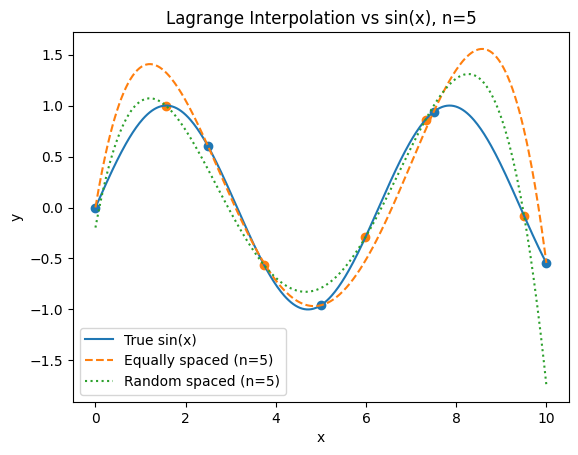

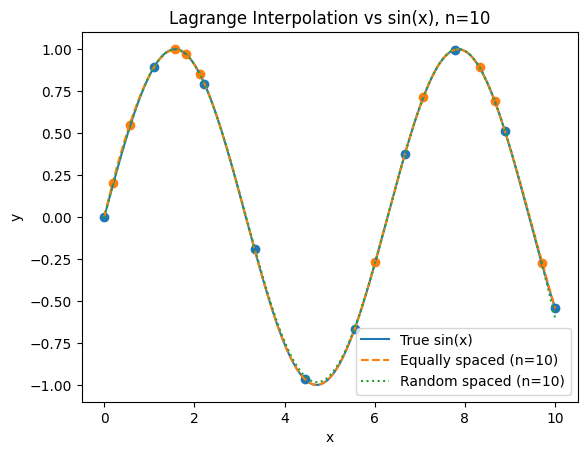

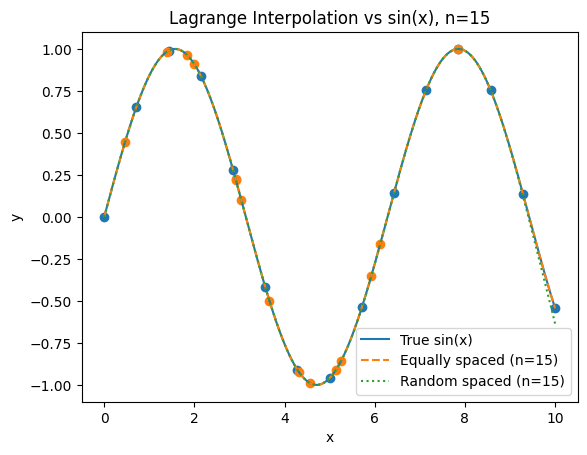

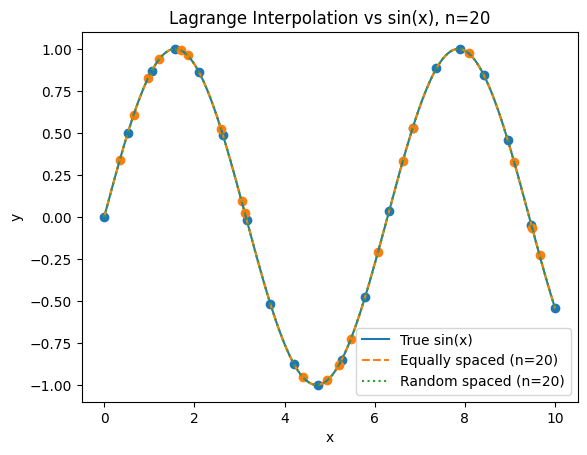

In [13]:
import matplotlib.pyplot as plt

def experiment_sin_interpolation():

    n_values = [5, 10, 15, 20]

    x_dense = np.linspace(0, 10, 400)

    true_y = np.sin(x_dense)

    for n in n_values:

        # equally spaced points
        x_eq = np.linspace(0, 10, n)
        y_eq = np.sin(x_eq)

        y_interp_eq = lagrange_interpolation(x_eq, y_eq, x_dense)

        # random spaced points
        x_rand = np.sort(np.random.uniform(0, 10, n))
        y_rand = np.sin(x_rand)

        y_interp_rand = lagrange_interpolation(x_rand, y_rand, x_dense)

        # plot
        plt.figure()

        plt.plot(x_dense, true_y, label="True sin(x)")

        plt.plot(x_dense, y_interp_eq,
                 linestyle="--",
                 label=f"Equally spaced (n={n})")

        plt.plot(x_dense, y_interp_rand,
                 linestyle=":",
                 label=f"Random spaced (n={n})")

        plt.scatter(x_eq, y_eq)
        plt.scatter(x_rand, y_rand)

        plt.title(f"Lagrange Interpolation vs sin(x), n={n}")
        plt.xlabel("x")
        plt.ylabel("y")

        plt.legend()

        plt.show()


experiment_sin_interpolation()

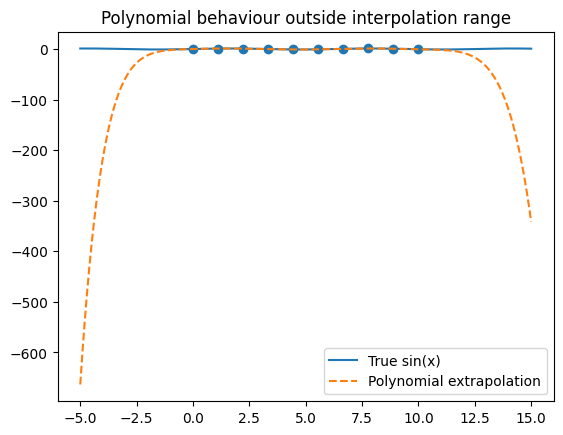

In [14]:
def extrapolation_test():

    x_points = np.linspace(0, 10, 10)
    y_points = np.sin(x_points)

    # evaluate outside range
    x_extra = np.linspace(-5, 15, 400)

    y_extra = lagrange_interpolation(x_points, y_points, x_extra)

    plt.figure()

    plt.plot(x_extra, np.sin(x_extra), label="True sin(x)")

    plt.plot(x_extra, y_extra,
             linestyle="--",
             label="Polynomial extrapolation")

    plt.scatter(x_points, y_points)

    plt.title("Polynomial behaviour outside interpolation range")

    plt.legend()

    plt.show()


extrapolation_test()

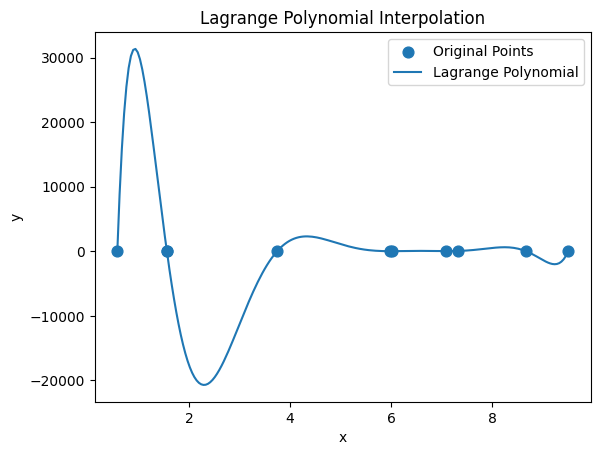

In [15]:
def generate_points(n, x_range=(0, 10), seed=42):
    """
    Generate n random (x, y) points.

    Returns:
        x (np.ndarray), y (np.ndarray)
    """
    np.random.seed(seed)

    # Generate sorted x for better plotting
    x = np.sort(np.random.uniform(x_range[0], x_range[1], n))

    # Random y values
    y = np.random.uniform(0, 100, n)

    return x, y

n = 10
x_points, y_points = generate_points(n)

# Step 2: Create smooth x values for plotting
x_vals = np.linspace(min(x_points), max(x_points), 200)

# Step 3: Interpolate
y_vals = lagrange_interpolation(x_points, y_points, x_vals)

# Step 4: Plot
plt.scatter(x_points, y_points, label="Original Points", s=60)
plt.plot(x_vals, y_vals, label="Lagrange Polynomial")

plt.title("Lagrange Polynomial Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Task 2 Critical Analysis
For y = sin(x), follow the intructions :

1. Sample points with increasing \( n \): 5, 10, 15, 20
2. Plot lagrange polynomial interpolation curve.

Answer the following:

- Explain about the approximation curve you get at the boundaries, middle of the plot and the curve between any two points.
- Where the error is largest (compare with a random subset points in sin(x) curve and the predicted curve) and why?
- Compare two cases which produces more stable interpolation: Equally spaced points and Randomly spaced points
- Evaluate the polynomial outside the range of input points. Explain your observations.


# Task 2 — Critical Analysis

## Behaviour of Approximation Curve

We approximate the function:

$$
y = \sin(x)
$$

using Lagrange Polynomial Interpolation with increasing number of sample points:

$$
n = 5, 10, 15, 20
$$

The interpolating polynomial has degree:

$$
\text{degree} = n - 1
$$

---

## 1. Behaviour at Boundaries, Middle, and Between Points

### Behaviour at Boundaries ($x \approx 0$ and $x \approx 10$)

From the plots, the largest deviation between the interpolated polynomial and the true function occurs near the boundaries of the interval.

For small number of sample points (especially $n = 5$), the interpolated polynomial overshoots the sine curve. The predicted values exceed the true range of the sine function:

$$
-1 \le \sin(x) \le 1
$$

For example, when $n = 5$, the interpolated polynomial produces values greater than $1.5$ and less than $-1.5$.

This happens because polynomial interpolation uses a high-degree polynomial:

$$
P(x) = \sum_{i=0}^{n} y_i L_i(x)
$$

High-degree polynomials tend to oscillate near the boundaries of the interpolation interval. This behaviour is known as the **Runge Phenomenon**.

As the number of points increases to $n = 10, 15, 20$, the approximation improves significantly and oscillations near boundaries reduce.

---

### Behaviour in the Middle of the Interval ($x \approx 5$)

The interpolated polynomial closely matches the true function in the middle region of the interval.

This occurs because the middle region is surrounded by interpolation points on both sides, which stabilizes the polynomial behaviour.

As $n$ increases, the interpolated curve becomes almost identical to $\sin(x)$ across the domain.

---

### Behaviour Between Any Two Interpolation Points

The polynomial always passes exactly through the selected data points:

$$
P(x_i) = y_i
$$

Between two neighbouring interpolation points, the polynomial approximates the curvature of the sine function.

For small $n$, the curve may deviate slightly between points due to insufficient sampling.

As $n$ increases, spacing between points decreases and the approximation becomes smoother and more accurate.

---

## 2. Where the Error is Largest and Why

The interpolation error is largest near the boundaries:

$$
x \approx 0 \quad \text{and} \quad x \approx 10
$$

For small number of sample points ($n=5$), significant deviation is observed near the edges of the plot.

Reason:

The Lagrange basis polynomial is defined as:

$$
L_i(x) =
\prod_{j \ne i}
\frac{x - x_j}{x_i - x_j}
$$

Near the boundaries, interpolation points exist only on one side, which causes imbalance in the approximation.

Additionally, high degree polynomial terms:

$$
x^n
$$

grow rapidly near interval edges, increasing sensitivity to small variations.

Thus boundary regions show higher approximation error compared to the middle region.

---

## 3. Comparison of Stability: Equally Spaced vs Randomly Spaced Points

### Equally Spaced Points

Equally spaced points provide uniform coverage across the domain:

$$
x_i = 0, \frac{10}{n-1}, \frac{20}{n-1}, ..., 10
$$

Observed advantages:

• smoother interpolation curve  
• consistent approximation accuracy  
• reduced oscillations for moderate values of $n$

For $n = 10, 15, 20$, the interpolated curve almost perfectly overlaps with $\sin(x)$.

---

### Randomly Spaced Points

Random spacing leads to uneven distribution of sample points.

Observed behaviour:

• small oscillations in sparsely sampled regions  
• slightly larger deviations compared to equally spaced sampling  
• less predictable approximation accuracy

For small $n$, random spacing shows slightly larger deviation near boundaries.

---

### Stability Conclusion

Equally spaced points generally produce more stable interpolation because the domain is sampled uniformly.

As number of points increases:

$$
n \to 20
$$

difference between equally spaced and randomly spaced interpolation becomes very small.

---

## 4. Behaviour Outside Interpolation Range (Extrapolation)

The polynomial was evaluated outside the interpolation interval:

$$
-5 \le x \le 15
$$

while the original interpolation points lie in:

$$
0 \le x \le 10
$$

From the plot, the polynomial diverges rapidly outside the interpolation region.

Observed behaviour:

• polynomial values become very large in magnitude  
• predicted values drop below $-600$  
• large oscillations occur outside the interval  

Meanwhile, the true function remains bounded:

$$
-1 \le \sin(x) \le 1
$$

---

### Reason for Extrapolation Instability

Polynomial interpolation guarantees accuracy only within the interpolation interval.

Outside this range, polynomial behaviour is dominated by highest degree term:

$$
a_n x^n
$$

As $|x|$ increases:

$$
|P(x)| \to \infty
$$

Therefore, extrapolation using high-degree polynomial becomes unreliable.

---

Increasing the number of interpolation points improves approximation accuracy of Lagrange polynomial for smooth functions such as $\sin(x)$.

Key observations:

• interpolation error is largest near boundaries  
• equally spaced points provide more stable interpolation  
• increasing $n$ improves accuracy significantly  
• polynomial interpolation is reliable inside data range  
• polynomial extrapolation is unstable outside data range  

Thus, Lagrange interpolation works well for smooth functions within the observed interval but performs poorly for extrapolation.